# Song Blob Visualisation
Multi-blob renderer using genre + tag embeddings, mapped to RGB via PCA.

In [6]:
import json
import csv
import math
import numpy as np
import colorsys
from PIL import Image
from collections import defaultdict
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

DATA_DIR = "./data"
CSV_DIR  = f"{DATA_DIR}/csv"
EMB_DIR  = f"{DATA_DIR}/embeddings"

# ── Load embeddings ─────────────────────────────────────────────────────────
with open(f"{EMB_DIR}/genre_embeddings.json") as f: genre_raw = json.load(f)
with open(f"{EMB_DIR}/tag_embeddings.json")   as f: tag_raw   = json.load(f)

genres, tags         = list(genre_raw.keys()), list(tag_raw.keys())
genre2idx, tag2idx   = {g: i for i, g in enumerate(genres)}, {t: i for i, t in enumerate(tags)}

G = np.array(list(genre_raw.values()), dtype=np.float32)
T = np.array(list(tag_raw.values()),   dtype=np.float32)
G_norm = G / (np.linalg.norm(G, axis=1, keepdims=True) + 1e-9)
T_norm = T / (np.linalg.norm(T, axis=1, keepdims=True) + 1e-9)

print(f"genres: {len(genres)} (dim={G.shape[1]}) | tags: {len(tags)} (dim={T.shape[1]})")


genres: 1305 (dim=32) | tags: 985 (dim=64)


In [7]:
# ── Load songs + tags ──────────────────────────────────────────────────────
def read_csv(path):
    with open(path, encoding='utf-8', errors='replace') as f:
        reader = csv.reader(f, delimiter=';')
        headers = [h.strip().strip('"') for h in next(reader)[0].split(',')]
        return [dict(zip(headers, [p.strip().strip('"') for p in row]))
                for row in reader if len(row) == len(headers)]

song_lookup = {}
song_genres = defaultdict(set)
for row in read_csv(f"{CSV_DIR}/songs.csv"):
    sid = row['spotify_id']
    song_lookup[sid] = row
    song_genres[sid].add(row['genre_name'])

song_tags = defaultdict(dict)
for row in read_csv(f"{CSV_DIR}/tags.csv"):
    sid, tag = row['song_spotify_id'], row['tag'].lower().strip()
    pop = int(row['popularity']) if row['popularity'].isdigit() else 0
    if pop > song_tags[sid].get(tag, 0):
        song_tags[sid][tag] = pop

for sid in song_tags:
    song_tags[sid] = [t for t, _ in sorted(song_tags[sid].items(), key=lambda x: -x[1])[:8]]

print(f"Loaded {len(song_lookup):,} songs")


Loaded 203,842 songs


In [8]:
# ── PCA → RGB ──────────────────────────────────────────────────────────────
pca_genre = PCA(n_components=3).fit(G_norm)
pca_tag   = PCA(n_components=3).fit(T_norm)

def embedding_to_rgb(vec, pca, temp=3.0, hue_offset=0.15):
    p = np.tanh(pca.transform(vec.reshape(1, -1))[0] * temp)
    h = (np.arctan2(p[1], p[0]) / (2 * np.pi) + 0.5 + hue_offset) % 1.0
    s = np.clip(np.sqrt(p[0]**2 + p[1]**2) * 0.4 + 0.6, 0.65, 1.0)
    v = np.clip((p[2] + 1) / 2 * 0.35 + 0.65, 0.65, 1.0)
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    return np.array([r * 255, g * 255, b * 255], dtype=np.float32)

# manual overrides for genres where PCA mapping is wrong
COLOR_OVERRIDES = {
    "metal":     [150,   0,   0],
    "punk":      [180,  20,  20],
    "grunge":    [100,  60,  20],
    "rap":       [40,   40,  40],
    "hip hop":   [60,   60,  80],
    "folk":      [120, 180,  60],
    "country":   [210, 140,  50],
    "classical": [200, 200, 240],
    "ambient":   [80,  120, 200],
    "blues":     [30,   80, 180],
}
COLOR_OVERRIDES = {k: np.array(v, dtype=np.float32) for k, v in COLOR_OVERRIDES.items()}


In [9]:
# ── Multi-blob renderer ────────────────────────────────────────────────────
def generate_multi_blob(song, size=600, max_blobs=8, seed=None):
    rng = np.random.default_rng(seed)
    canvas = np.zeros((size, size, 3), dtype=np.float32)
    cx, cy = size // 2, size // 2
    y_grid, x_grid = np.mgrid[0:size, 0:size]
    radius_base = size * 0.18

    blobs = []

    # genre blobs (strong anchors)
    for genre in song.get('genres', []):
        t = genre.lower()
        if t in COLOR_OVERRIDES:
            color = COLOR_OVERRIDES[t]
        elif t in genre2idx:
            color = embedding_to_rgb(G_norm[genre2idx[t]], pca_genre)
        else:
            continue
        angle = rng.uniform(0, 2 * np.pi)
        r     = rng.uniform(0, size * 0.12)
        blobs.append((cx + np.cos(angle) * r, cy + np.sin(angle) * r, radius_base * 1.3, color))

    # tag blobs (smaller satellites)
    for tag in song.get('tags', []):
        if len(blobs) >= max_blobs: break
        t = tag.lower()
        if t not in tag2idx: continue
        color = embedding_to_rgb(T_norm[tag2idx[t]], pca_tag)
        angle = rng.uniform(0, 2 * np.pi)
        r     = rng.uniform(0, size * 0.2)
        blobs.append((cx + np.cos(angle) * r, cy + np.sin(angle) * r, radius_base * 0.7, color))

    if not blobs:
        return None

    for bx, by, radius, color in blobs:
        dist = np.sqrt((x_grid - bx)**2 + (y_grid - by)**2)
        mask = np.clip(1 - dist / radius, 0, 1) ** 2
        canvas += color[None, None, :] * mask[..., None] * 0.05

    canvas = np.clip(canvas, 0, 1)
    canvas = np.power(canvas, 0.75)
    return Image.fromarray((np.clip(canvas, 0, 1) * 255).astype(np.uint8))

def blob_from_spotify_id(sid, size=600, seed=None):
    if sid not in song_lookup: return None, None
    song = {
        'genres': sorted(song_genres.get(sid, [])),
        'tags':   song_tags.get(sid, []),
    }
    return generate_multi_blob(song, size=size, seed=seed), song


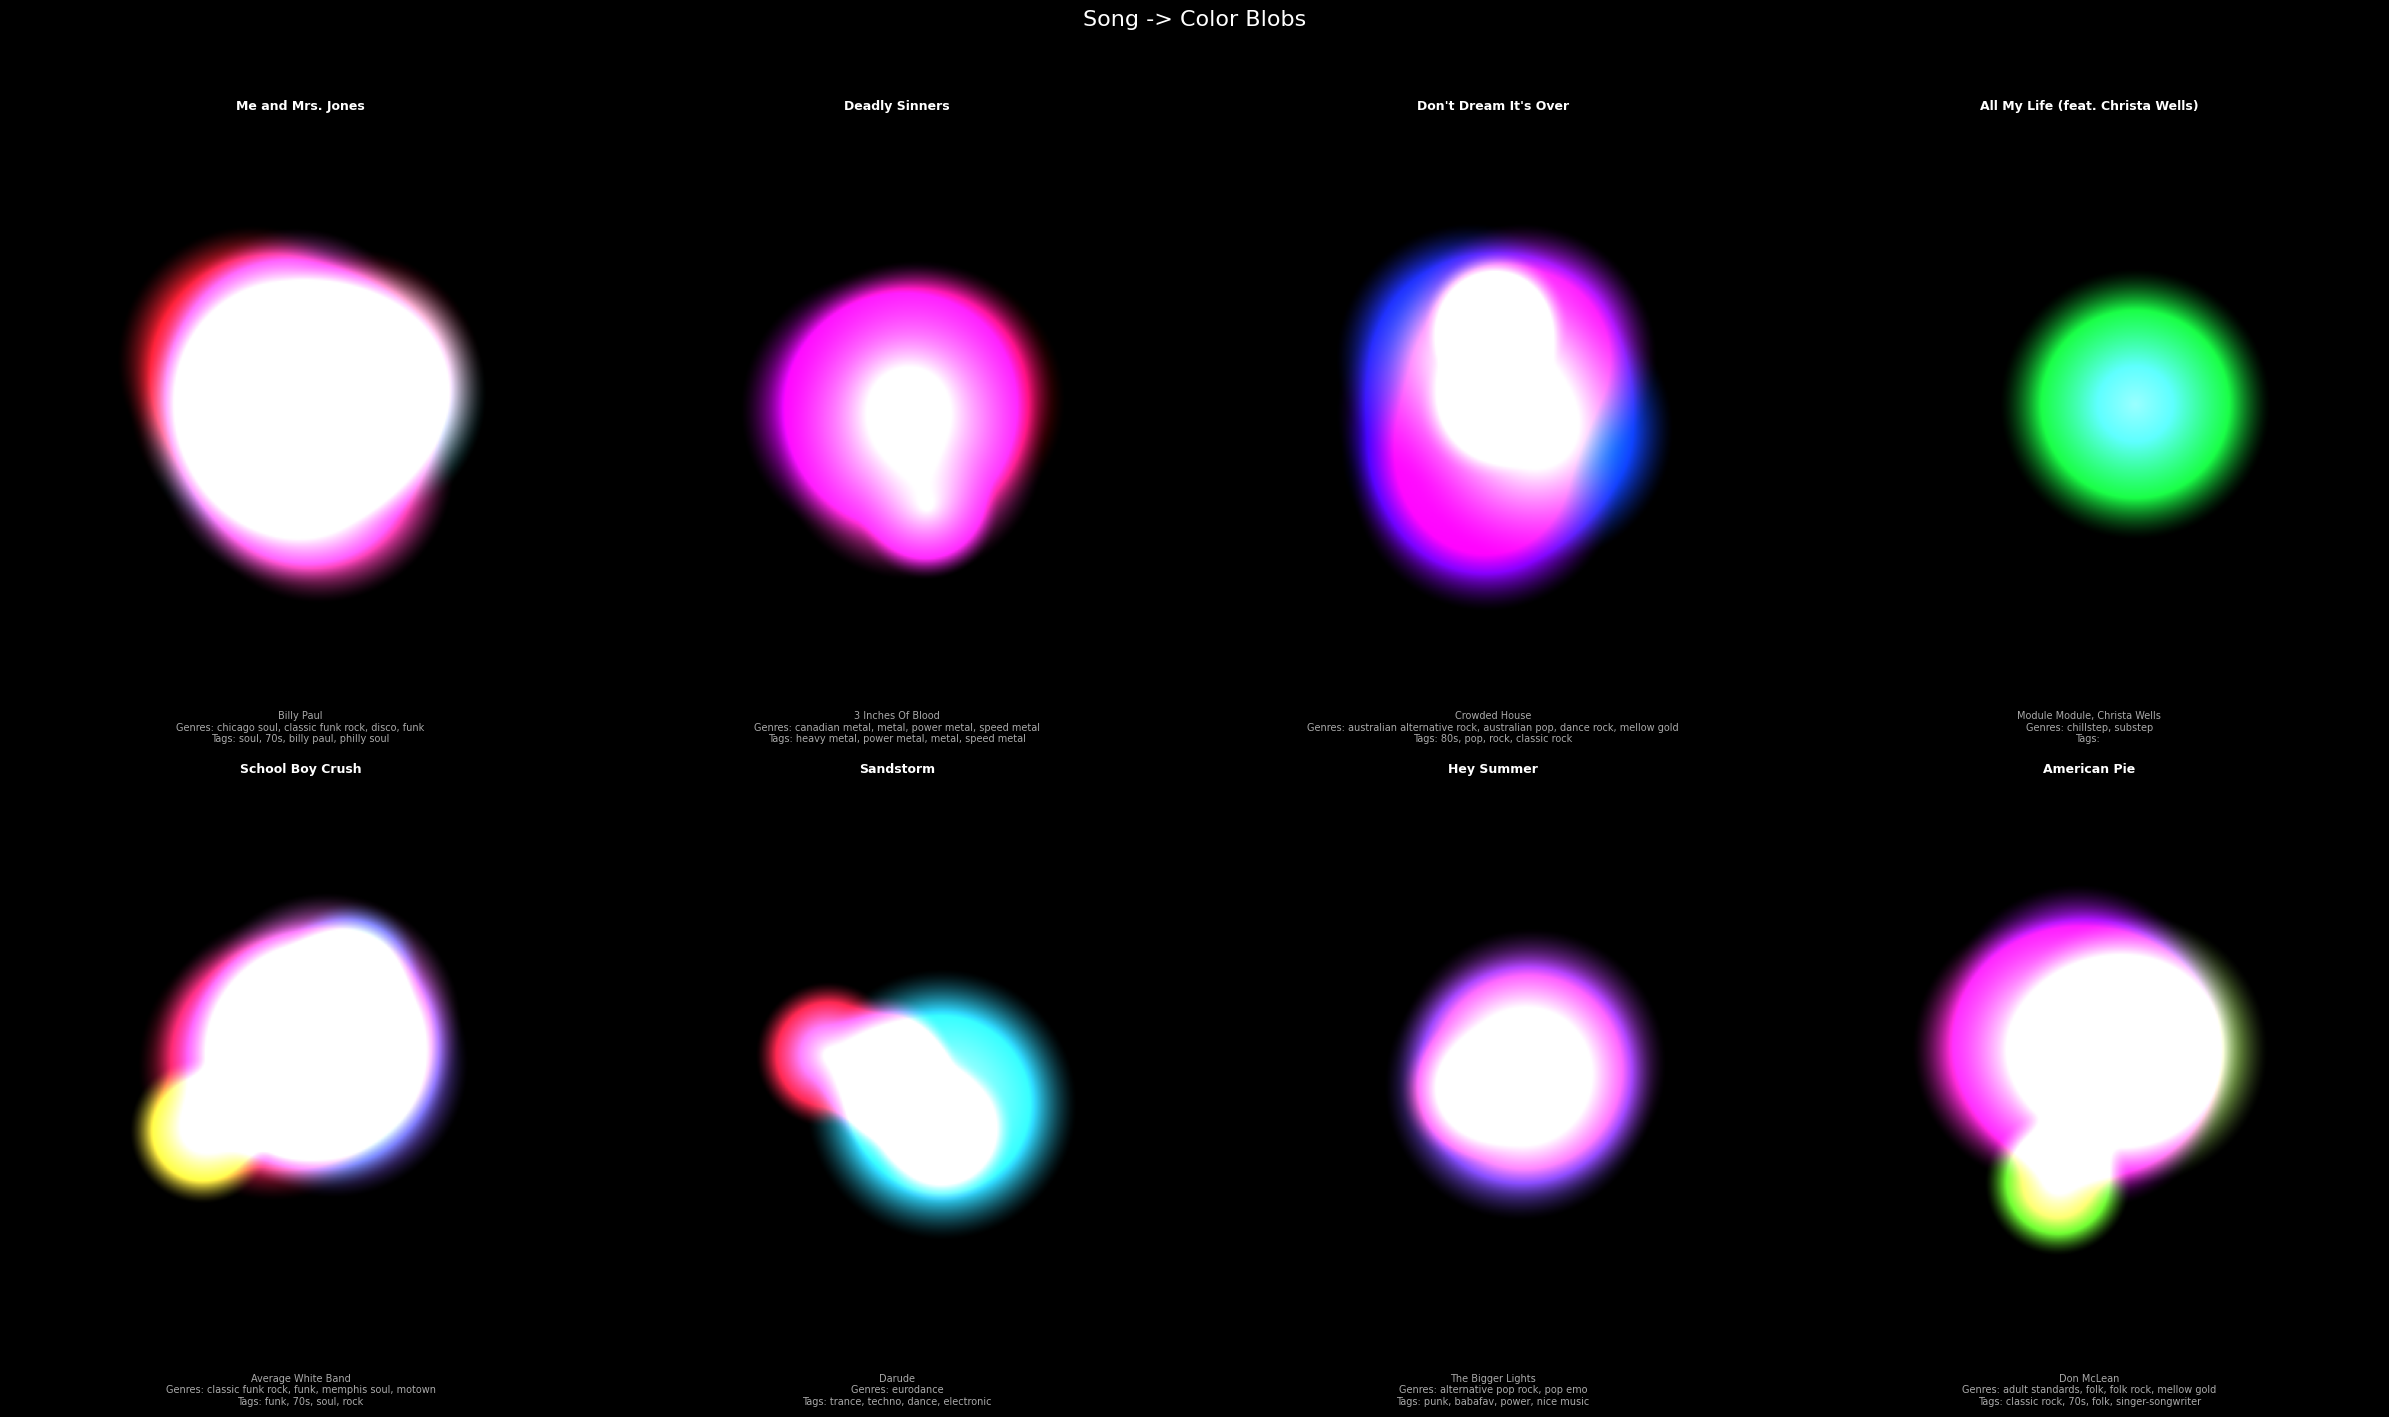

In [10]:
# ── Plot test songs ────────────────────────────────────────────────────────
TEST_IDS = [
    "5GYcaVfaFBHe2gzA6Oybgj",  # Me and Mrs. Jones      - soul blues
    "52mxPsGKbfyElOA0FCtc0l",  # Deadly Sinners         - thrash metal
    "68wIBE5dVVX8RyfZCJnAj5",  # Don't Dream It's Over  - alt rock
    "4YP2nQliU8KsUB74XTP5aP",  # All My Life            - chillstep
    "0wNUTleNAhiAFPghCxLt27",  # School Boy Crush       - funk
    "24CXuh2WNpgeSYUOvz14jk",  # Sandstorm              - eurodance
    "4ygIRtbrrMlL8fBBADwzEj",  # Hey Summer             - pop emo
    "2QgWuCtBpNIpl5trmKCxRf",  # American Pie           - folk rock
]

n_cols = 4
n_rows = math.ceil(len(TEST_IDS) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 7 * n_rows))
fig.patch.set_facecolor('#000000')
axes = axes.flatten()

for i, sid in enumerate(TEST_IDS):
    img, song = blob_from_spotify_id(sid, size=400, seed=hash(sid) & 0xffffffff)
    if img is None:
        axes[i].axis('off')
        continue

    row        = song_lookup.get(sid, {})
    genres_str = ', '.join(song['genres'][:4])
    tags_str   = ', '.join(song['tags'][:4])

    axes[i].imshow(img)
    axes[i].set_facecolor('#000000')
    axes[i].set_title(row.get('name', sid), color='white', fontsize=9, fontweight='bold', pad=6)
    axes[i].set_xlabel(
        f"{row.get('artist','')}\nGenres: {genres_str}\nTags: {tags_str}",
        color='#aaaaaa', fontsize=7, labelpad=8
    )
    axes[i].set_xticks([]); axes[i].set_yticks([])
    for spine in axes[i].spines.values(): spine.set_visible(False)

for j in range(len(TEST_IDS), len(axes)): axes[j].axis('off')

plt.suptitle("Song -> Color Blobs", fontsize=16, color='white', y=1.01)
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/multi_blobs.png", dpi=150, bbox_inches='tight', facecolor='#000000')
plt.show()
